# Modern Portfolio Theory - Services Walkthrough

This notebook is a detailed, function-by-function walkthrough of the backend services in `backend/app/services`.
It mirrors the production logic while adding EDA and practical usage steps.

## What are we doing
- Load and validate ticker symbols
- Fetch historical price data and compute returns
- Perform basic EDA
- Compute annualized returns and correlations
- Run portfolio optimization and visualize the frontier

## Core formulas (reference)
Expected portfolio return:
$$
E(R_p) = \sum_{i=1}^{n} w_i E(R_i)
$$
Portfolio variance:
$$
\sigma_p^2 = \sum_{i=1}^{n} \sum_{j=1}^{n} w_i w_j \text{Cov}(R_i, R_j)
$$

## Notes 
- This notebook assumes internet access for Yahoo Finance (yfinance).
- If any ticker is invalid or the date range is too short, the fetch step will raise a clear error.
- The function definitions below match the backend services for clarity and traceability.

In [1]:
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests
import scipy.optimize as sco
from scipy.interpolate import interp1d

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
np.random.seed(42)

plt.style.use("seaborn-v0_8")

## Configuration
Update tickers and dates to match your use case. The benchmark daily return is used as the MAR for Sortino.

In [2]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN"]
start_date = "2022-01-01"
end_date = "2025-01-01"
benchmark_ticker = "^GSPC"
risk_free_rate = 0.0
num_portfolios = 3000

# Service: data_fetcher.py
This service handles data retrieval and validation from Yahoo Finance. Each function below mirrors the backend implementation.

## Function: fetch_stock_data
Downloads adjusted close prices and computes daily returns, mean returns, and covariance matrix. It also handles the single-ticker edge case.

In [3]:
def fetch_stock_data(tickers: list[str], start: str, end: str):
    """
    Download historical closing prices and compute daily returns,
    mean returns, and covariance matrix.

    Returns:
        tuple: (daily_returns, mean_returns, cov_matrix)
    """
    start_date = dt.datetime.strptime(start, "%Y-%m-%d")
    end_date = dt.datetime.strptime(end, "%Y-%m-%d")

    stock_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]

    # Handle single-stock edge case (yf returns Series not DataFrame)
    if isinstance(stock_data, pd.Series):
        stock_data = stock_data.to_frame(name=tickers[0])

    daily_returns = stock_data.pct_change(fill_method=None).dropna()

    if daily_returns.empty:
        raise ValueError(
            "Could not fetch sufficient data. Some tickers may be invalid (e.g., use 'BRK-B' instead of 'BRK.B') or the date range is too narrow."
        )

    mean_returns = daily_returns.mean()
    cov_matrix = daily_returns.cov()

    return daily_returns, mean_returns, cov_matrix

## Function: fetch_benchmark
Fetches the benchmark data and computes the average daily return (scalar). This is used as the MAR for the Sortino ratio.

In [4]:
def fetch_benchmark(ticker: str, start: str, end: str):
    """
    Fetch benchmark data and return the average daily return (scalar).
    Used as MAR for Sortino ratio.
    """
    start_date = dt.datetime.strptime(start, "%Y-%m-%d")
    end_date = dt.datetime.strptime(end, "%Y-%m-%d")

    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)["Close"]
    daily_returns = data.pct_change().dropna()

    # Force scalar
    avg_daily = daily_returns.mean()
    if hasattr(avg_daily, "item"):
        avg_daily = avg_daily.item()
    elif hasattr(avg_daily, "squeeze"):
        avg_daily = float(avg_daily.squeeze())

    return float(avg_daily)

## Function: search_tickers
Uses Yahoo Finance search API to find ticker symbols. Useful for frontend typeahead experiences.

In [5]:
def search_tickers(query: str):
    """
    Search for stock tickers using Yahoo Finance's native search API.
    Returns a list of dicts with ticker info.
    """
    results = []
    if not query:
        return results

    try:
        url = "https://query2.finance.yahoo.com/v1/finance/search"
        params = {"q": query, "quotesCount": 6, "newsCount": 0}
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
        }
        response = requests.get(url, params=params, headers=headers, timeout=5)
        response.raise_for_status()
        data = response.json()

        quotes = data.get("quotes", [])
        for q in quotes:
            # We mostly care about equities/ETFs, but allow all for now.
            if "symbol" in q:
                results.append({
                    "ticker": q.get("symbol"),
                    "name": q.get("shortname", q.get("longname", "Unknown")),
                    "exchange": q.get("exchange", "Unknown"),
                    "type": q.get("quoteType", "Unknown")
                })
    except Exception as e:
        print(f"Error searching tickers: {e}")

    return results

## Function: get_tickers_info
Fetches the latest price, name, and daily change for a list of tickers.

In [6]:
def get_tickers_info(tickers: list[str]):
    """
    Fetch the latest price, name, and daily change for multiple tickers using yfinance.
    """
    if not tickers:
        return {}

    result = {}
    for symbol in tickers:
        try:
            ticker = yf.Ticker(symbol)
            info = ticker.info

            # yfinance info dict can vary, try a few common keys
            price = info.get("currentPrice") or info.get("regularMarketPrice") or info.get("previousClose") or 0.0
            prev_close = info.get("previousClose") or price

            if prev_close and prev_close > 0:
                change_percent = ((price - prev_close) / prev_close) * 100
            else:
                change_percent = 0.0

            name = info.get("shortName") or info.get("longName") or symbol

            result[symbol] = {
                "name": name,
                "price": float(price),
                "change": float(change_percent),
                "isUp": change_percent >= 0
            }
        except Exception as e:
            print(f"Error fetching info for {symbol}: {e}")

    return result

## Function: validate_tickers
Checks which tickers return valid recent history from Yahoo Finance.

In [7]:
def validate_tickers(tickers: list[str]):
    """
    Validate that a list of tickers have data on Yahoo Finance.
    Returns (valid, invalid) tuple of lists.
    """
    valid = []
    invalid = []

    for ticker_str in tickers:
        try:
            ticker = yf.Ticker(ticker_str.upper())
            hist = ticker.history(period="5d")
            if len(hist) > 0:
                valid.append(ticker_str.upper())
            else:
                invalid.append(ticker_str.upper())
        except Exception:
            invalid.append(ticker_str.upper())

    return valid, invalid

## Fetch data and basic checks
We validate tickers, fetch daily returns, then compute mean returns and covariance matrix.

In [8]:
valid_tickers, invalid_tickers = validate_tickers(tickers)
print("Valid tickers:", valid_tickers)
print("Invalid tickers:", invalid_tickers)

daily_returns, mean_returns, cov_matrix = fetch_stock_data(valid_tickers, start_date, end_date)
benchmark_daily_return = fetch_benchmark(benchmark_ticker, start_date, end_date)

daily_returns.head()

Valid tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
Invalid tickers: []


[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2022-01-04,-0.012692,-0.016916,-0.004083,-0.017147
2022-01-05,-0.026600,-0.018893,-0.045876,-0.038388
2022-01-06,-0.016693,-0.006711,-0.000200,-0.007902
2022-01-07,0.000988,-0.004288,-0.005303,0.000510
2022-01-10,0.000116,-0.006570,0.012061,0.000732


## EDA: price trends
We download price data again for visual EDA. This keeps the fetch service intact while allowing charts.

[*********************100%***********************]  4 of 4 completed


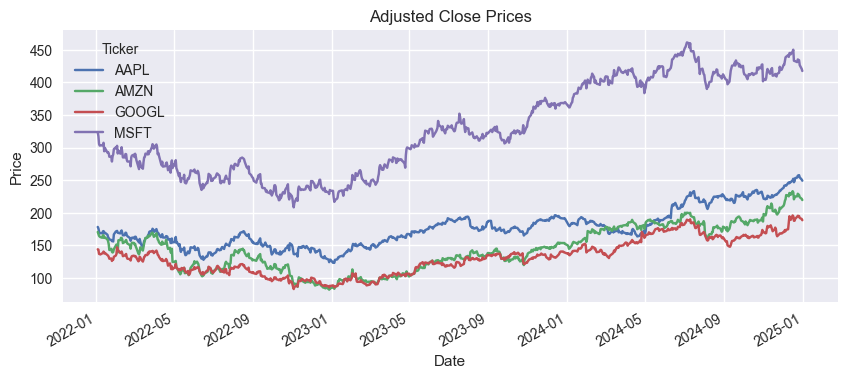

In [9]:
price_data = yf.download(valid_tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
if isinstance(price_data, pd.Series):
    price_data = price_data.to_frame(name=valid_tickers[0])

ax = price_data.plot(title="Adjusted Close Prices", figsize=(10, 4))
ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.show()

## EDA: returns distribution and summary
A quick look at daily return stats and distributions.

Ticker,AAPL,AMZN,GOOGL,MSFT
count,752.000000,752.000000,752.000000,752.000000
mean,0.000591,0.000627,0.000572,0.000491
std,0.017067,0.024147,0.020627,0.017372
min,-0.058680,-0.140494,-0.095094,-0.077156
25%,-0.008437,-0.012626,-0.011606,-0.008516
50%,0.001117,0.000331,0.001098,0.000789
75%,0.009751,0.014102,0.011492,0.010603
max,0.088974,0.135359,0.102244,0.082268


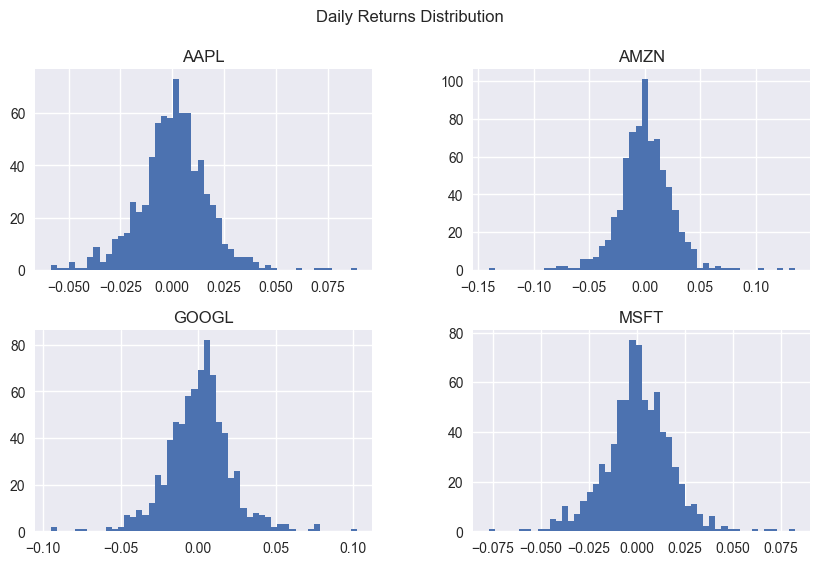

In [10]:
display(daily_returns.describe())

daily_returns.hist(figsize=(10, 6), bins=50)
plt.suptitle("Daily Returns Distribution")
plt.show()

## EDA: 2
Cumulative returns, rolling volatility, and drawdowns provide a quick view of growth, risk changes, and peak-to-trough declines.

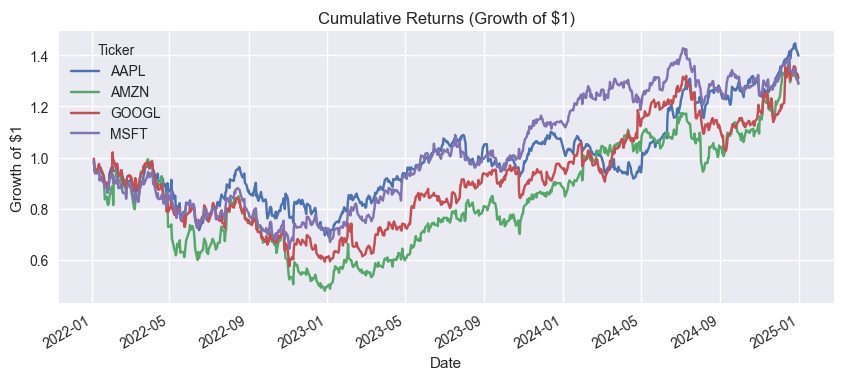

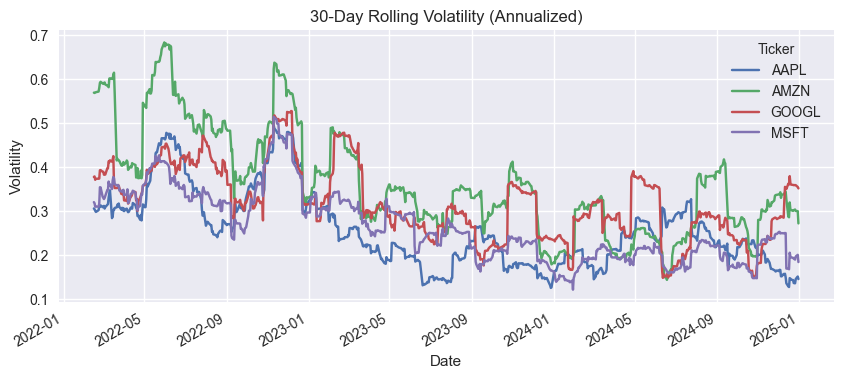

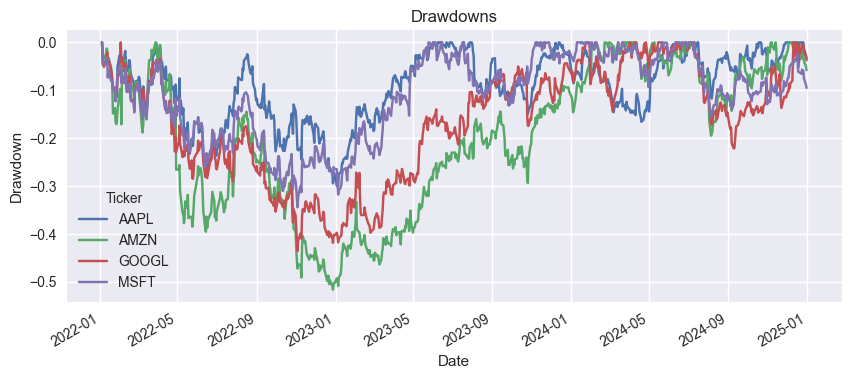

In [27]:
# Extra EDA visuals
cumulative_returns = (1 + daily_returns).cumprod()
ax = cumulative_returns.plot(figsize=(10, 4), title="Cumulative Returns (Growth of $1)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

rolling_vol = daily_returns.rolling(30).std() * np.sqrt(252)
ax = rolling_vol.plot(figsize=(10, 4), title="30-Day Rolling Volatility (Annualized)")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
plt.show()

running_max = cumulative_returns.cummax()
drawdowns = (cumulative_returns / running_max) - 1
ax = drawdowns.plot(figsize=(10, 4), title="Drawdowns")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
plt.show()


# Service: returns.py
This service computes annualized returns from daily returns.

## Function: compute_annualized_returns
Annualized return is the mean daily return times 252 (trading days), expressed as a percentage.

In [11]:
def compute_annualized_returns(daily_returns: pd.DataFrame) -> dict:
    """
    Calculate annualized returns from daily returns.
    Returns a dict mapping stock ticker to annualized return (as percentage).
    """
    daily_mean = daily_returns.mean()
    annualized = daily_mean * 252

    result = {}
    for stock in annualized.index:
        result[str(stock)] = round(float(annualized[stock]) * 100, 2)

    stocks = [str(s) for s in annualized.index.tolist()]
    return result, stocks

## Run returns service
We compute annualized returns and display them in a table.

In [12]:
annualized_returns, annualized_stocks = compute_annualized_returns(daily_returns)
pd.DataFrame({"ticker": annualized_stocks, "annualized_return_pct": [annualized_returns[s] for s in annualized_stocks]})

,ticker,annualized_return_pct
0,AAPL,14.90
1,AMZN,15.81
2,GOOGL,14.41
3,MSFT,12.38


# Service: correlation.py
This service computes the correlation matrix and serializes it into a JSON-friendly dict-of-dicts.

## Function: compute_correlation_matrix
Uses pandas to compute correlations from daily returns, then normalizes keys to strings.

In [13]:
def compute_correlation_matrix(daily_returns: pd.DataFrame) -> dict:
    """
    Compute the correlation matrix from daily returns.
    Returns a dict-of-dicts suitable for JSON serialization.
    """
    corr_matrix = daily_returns.corr()

    # Convert to nested dict with string keys
    result = {}
    for col in corr_matrix.columns:
        col_name = str(col)
        result[col_name] = {}
        for idx in corr_matrix.index:
            idx_name = str(idx)
            result[col_name][idx_name] = round(float(corr_matrix.loc[idx, col]), 4)

    stocks = [str(c) for c in corr_matrix.columns.tolist()]
    return result, stocks

## Run correlation service
We compute the correlation matrix and display a simple heatmap.

,AAPL,AMZN,GOOGL,MSFT
AAPL,1.0000,0.5634,0.6224,0.6848
AMZN,0.5634,1.0000,0.6498,0.6893
GOOGL,0.6224,0.6498,1.0000,0.6942
MSFT,0.6848,0.6893,0.6942,1.0000


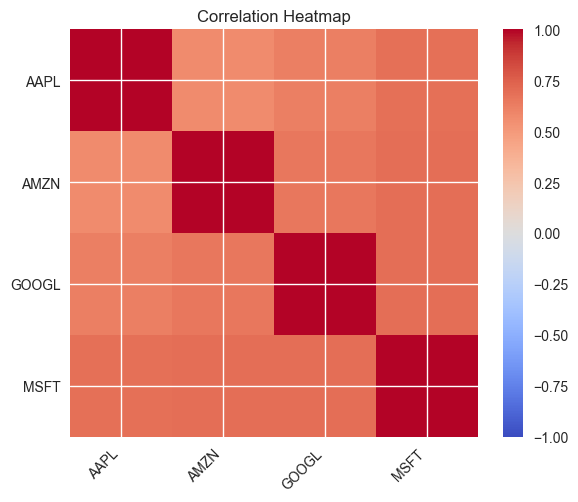

In [14]:
corr_dict, corr_stocks = compute_correlation_matrix(daily_returns)
corr_df = pd.DataFrame(corr_dict)
display(corr_df)

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index)
fig.colorbar(cax)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Service: optimizer.py
This service contains the core Modern Portfolio Theory optimization functions. Each function below is shown in its own cell with context.

## Function: portfolio_performance
Computes annualized return and volatility for a portfolio weight vector.

In [15]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    """Calculate annualized portfolio return and volatility."""
    annual_return = np.dot(mean_returns, weights) * 252
    port_variance = np.dot(weights.T, np.dot(cov_matrix, weights)) * 252
    port_volatility = np.sqrt(port_variance)
    return float(annual_return), float(port_volatility)

## Function: negative_sharpe_ratio
We minimize the negative Sharpe ratio to find the maximum Sharpe portfolio.

In [16]:
def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0):
    """Returns the negative Sharpe ratio (for minimization)."""
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - risk_free_rate) / vol

## Function: max_sharpe_ratio
Optimizes weights to maximize Sharpe ratio with constraints that weights sum to 1 and remain within bounds.

In [17]:
def max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate=0, constraint_set=(0, 1)):
    """Optimize for the maximum Sharpe ratio portfolio."""
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix, risk_free_rate)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple(constraint_set for _ in range(num_assets))

    result = sco.minimize(
        negative_sharpe_ratio,
        num_assets * [1.0 / num_assets],
        args=args,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
    )
    return result

## Function: portfolio_variance
Returns annualized variance for a given weight vector.

In [18]:
def portfolio_variance(weights, mean_returns, cov_matrix):
    """Returns the portfolio variance (annualized)."""
    return np.dot(weights.T, np.dot(cov_matrix, weights)) * 252

## Function: min_variance
Finds the minimum volatility portfolio under weight constraints.

In [19]:
def min_variance(mean_returns, cov_matrix, constraint_set=(0, 1)):
    """Optimize for the minimum volatility portfolio."""
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple(constraint_set for _ in range(num_assets))

    result = sco.minimize(
        portfolio_variance,
        num_assets * [1.0 / num_assets],
        args=args,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
    )
    return result

## Function: efficient_optimization
Minimizes variance for a target return to build the efficient frontier.

In [20]:
def efficient_optimization(mean_returns, cov_matrix, target_return, constraint_set=(0, 1)):
    """Find the minimum variance portfolio for a given target return."""
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix)
    constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.dot(mean_returns, x) * 252 - target_return}
    )
    bounds = tuple(constraint_set for _ in range(num_assets))

    result = sco.minimize(
        portfolio_variance,
        num_assets * [1.0 / num_assets],
        args=args,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
    )
    return result

## Function: random_portfolios
Generates random portfolios for visualization and filtering.

In [21]:
def random_portfolios(mean_returns, cov_matrix, num_portfolios=5000, risk_free_rate=0):
    """Generate random portfolios for visualization."""
    num_assets = len(mean_returns)
    results_ret = []
    results_vol = []

    weights = np.random.dirichlet(np.ones(num_assets), num_portfolios)
    for i in range(num_portfolios):
        ret, vol = portfolio_performance(weights[i], mean_returns, cov_matrix)
        results_ret.append(ret * 100)
        results_vol.append(vol * 100)

    return results_ret, results_vol

## Function: filter_random_portfolios
Filters random portfolios to only keep those below the efficient frontier.

In [22]:
def filter_random_portfolios(random_rets, random_vols, ef_vols, target_rets):
    """Filter random portfolios to lie below the efficient frontier."""
    ef_interp = interp1d(ef_vols, target_rets, kind="linear", fill_value="extrapolate")
    filtered_rets = []
    filtered_vols = []

    for ret, vol in zip(random_rets, random_vols):
        if ret <= ef_interp(vol):
            filtered_rets.append(ret)
            filtered_vols.append(vol)

    return filtered_rets, filtered_vols

## Function: sortino_ratio
Computes the Sortino ratio using downside deviation and the MAR.

In [23]:
def sortino_ratio(weights, daily_returns, MAR):
    """Calculate the Sortino Ratio for a portfolio."""
    portfolio_daily = daily_returns.dot(weights)
    downside_returns = portfolio_daily[portfolio_daily < MAR]

    if len(downside_returns) == 0:
        return float('nan')

    downside_std = np.std(downside_returns)
    annual_downside = downside_std * np.sqrt(252)
    annual_portfolio_return = portfolio_daily.mean() * 252

    return float((annual_portfolio_return - MAR * 252) / annual_downside)

## Function: calculate_full_optimization
Runs the full pipeline and returns a JSON-ready summary for the API response.

In [24]:
def calculate_full_optimization(
    mean_returns,
    cov_matrix,
    daily_returns,
    risk_free_rate=0,
    constraint_set=(0, 1),
    num_portfolios=5000,
    benchmark_daily_return=0
):
    """
    Run the complete optimization pipeline.
    Returns a dict with all results ready for the API response.
    """
    # Max Sharpe portfolio
    max_sharpe_obj = max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate, constraint_set)
    sr_ret, sr_vol = portfolio_performance(max_sharpe_obj.x, mean_returns, cov_matrix)
    sr_ret_pct = sr_ret * 100
    sr_vol_pct = sr_vol * 100
    sr_sharpe = sr_ret / sr_vol if sr_vol != 0 else 0

    max_sharpe_allocations = []
    for stock, weight in zip(mean_returns.index, max_sharpe_obj.x):
        max_sharpe_allocations.append({
            "stock": str(stock),
            "weight": round(float(weight) * 100, 2)
        })

    # Min Volatility portfolio
    min_vol_obj = min_variance(mean_returns, cov_matrix, constraint_set)
    mv_ret, mv_vol = portfolio_performance(min_vol_obj.x, mean_returns, cov_matrix)
    mv_ret_pct = mv_ret * 100
    mv_vol_pct = mv_vol * 100
    mv_sharpe = mv_ret / mv_vol if mv_vol != 0 else 0

    min_vol_allocations = []
    for stock, weight in zip(mean_returns.index, min_vol_obj.x):
        min_vol_allocations.append({
            "stock": str(stock),
            "weight": round(float(weight) * 100, 2)
        })

    # Efficient Frontier
    target_returns_frac = np.linspace(mv_ret, sr_ret * 1.2, 50)
    ef_vols = []
    ef_rets = []
    for ret in target_returns_frac:
        try:
            eff = efficient_optimization(mean_returns, cov_matrix, ret, constraint_set)
            eff_vol = np.sqrt(eff.fun) * 100
            ef_vols.append(float(eff_vol))
            ef_rets.append(float(ret * 100))
        except Exception:
            continue

    # Random portfolios (filtered)
    rand_rets, rand_vols = random_portfolios(mean_returns, cov_matrix, num_portfolios, risk_free_rate)

    if ef_vols and ef_rets:
        filt_rets, filt_vols = filter_random_portfolios(rand_rets, rand_vols, ef_vols, ef_rets)
    else:
        filt_rets, filt_vols = rand_rets, rand_vols

    # Sortino ratio
    sort_ratio = sortino_ratio(max_sharpe_obj.x, daily_returns, benchmark_daily_return)

    return {
        "max_sharpe": {
            "allocations": max_sharpe_allocations,
            "annual_return": round(sr_ret_pct, 2),
            "annual_volatility": round(sr_vol_pct, 2),
            "sharpe_ratio": round(sr_sharpe, 2)
        },
        "min_volatility": {
            "allocations": min_vol_allocations,
            "annual_return": round(mv_ret_pct, 2),
            "annual_volatility": round(mv_vol_pct, 2),
            "sharpe_ratio": round(mv_sharpe, 2)
        },
        "sortino_ratio": round(sort_ratio, 2) if not np.isnan(sort_ratio) else None,
        "efficient_frontier": {
            "returns": ef_rets,
            "volatilities": ef_vols
        },
        "random_portfolios": {
            "returns": filt_rets,
            "volatilities": filt_vols
        }
    }

## Run the optimization pipeline
This step creates the max Sharpe and min volatility portfolios, plus the frontier and random samples.

In [25]:
results = calculate_full_optimization(
    mean_returns=mean_returns,
    cov_matrix=cov_matrix,
    daily_returns=daily_returns,
    risk_free_rate=risk_free_rate,
    num_portfolios=num_portfolios,
    benchmark_daily_return=benchmark_daily_return
)

max_sharpe_df = pd.DataFrame(results["max_sharpe"]["allocations"])
min_vol_df = pd.DataFrame(results["min_volatility"]["allocations"])

display(max_sharpe_df)
display(min_vol_df)
print("Sortino ratio:", results["sortino_ratio"])

,stock,weight
0,AAPL,69.70
1,AMZN,10.90
2,GOOGL,13.96
3,MSFT,5.43


,stock,weight
0,AAPL,49.81
1,AMZN,0.00
2,GOOGL,8.09
3,MSFT,42.09


Sortino ratio: 0.36


## Efficient frontier plot
We plot filtered random portfolios and the efficient frontier curve.

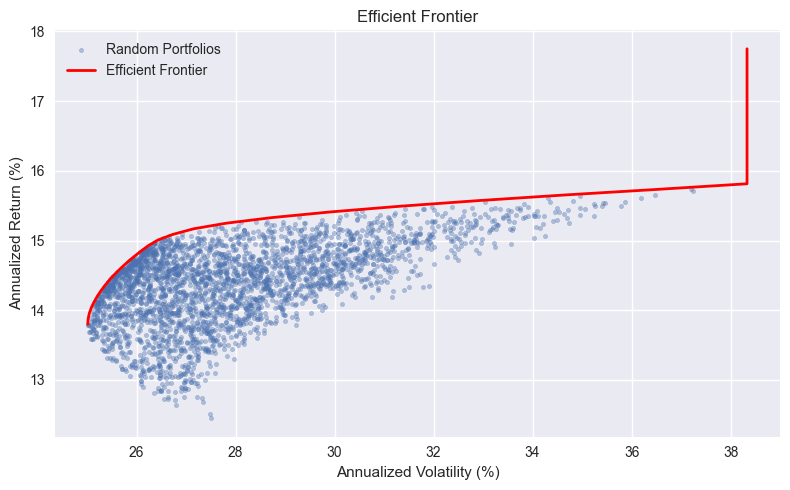

In [26]:
ef = results["efficient_frontier"]
rp = results["random_portfolios"]

plt.figure(figsize=(8, 5))
plt.scatter(rp["volatilities"], rp["returns"], s=10, alpha=0.4, label="Random Portfolios")
plt.plot(ef["volatilities"], ef["returns"], color="red", linewidth=2, label="Efficient Frontier")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Efficient Frontier")
plt.legend()
plt.tight_layout()
plt.show()